<a href="https://colab.research.google.com/github/Tech-Matt/arduino-tiny-ml/blob/main/GestureRecognitionTraining.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Preparing the Python environment with TensorFlow.

In [2]:
!apt-get -qq install xxd
!pip install pandas numpy matplotlib
!pip install tensorflow

In [51]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as ts

filenames = ["rest.csv","left_right.csv","down_up.csv","circle.csv"]
gestures = ["Rest","Left-right","Down-Up","Circle"]

dims = [" aX"," aY"," aZ"," gX"," gY"," gZ"]
dims_min = [
    [-4.,0.,0.,-4.,-4.,0.],
    [-4.,0.,0.,-4.,-4.,0.],
    [-4.,0.,0.,-4.,-4.,0.],
    [-2000.,0.,0.,-2000.,-2000.,0.],
    [-2000.,0.,0.,-2000.,-2000.,0.],
    [-2000.,0.,0.,-2000.,-2000.,0.]]

dims_max = [
    [4.,4.,4.,4.,4.,128000000.],
    [4.,4.,4.,4.,4.,128000000.],
    [4.,4.,4.,4.,4.,128000000.],
    [2000.,2000.,2000.,2000.,2000.,128000000.],
    [2000.,2000.,2000.,2000.,2000.,128000000.],
    [2000.,2000.,2000.,2000.,2000.,128000000.]]

features = [" Mean"," Std"," RMS"," Min"," Max", " PSD"]

windows_per_gesture = 100
samples_per_window = 128

csv = []
for filename in filenames:
  csv.append(pd.read_csv("/content/"+filename))

Each *.csv* file contains the measurement of the accelerometer and gyroscope for a specific gesture that should be used as training samples. The values are encoded with the following format:

\begin{array}{c|c|c|c|c|c|c|}
\text{sample}&\text{feature}&\text{aX}&\text{aY}&\text{aZ}&\text{gX}&\text{gY}&\text{gZ}\\
1 & x&\dots&\dots&\dots&\dots&\dots&\dots \\
2 & y&\dots&\dots&\dots&\dots&\dots&\dots
\end{array}
the columns from **ax** to **gz** indicates the campionated and processed values for the corresponding feature in the first column.

for each sample there are 6 rows that enumerates the values for each axes of the accelerometer and the gyroscope.
for example:

```
sample, feature, aX, aY, aZ, gX, gY, gZ
1, Mean, -0.0496,0.9746,0.1052,1.2507,2.1276,-2.7504
1, Std, 0.0628,0.1466,0.2108,24.2634,41.8278,19.7275
1, RMS, 0.0800,0.9856,0.2356,24.2957,41.8819,19.9183
1, Min, -0.1667,0.6788,-0.3120,-110.6567,-93.6890,-66.1011
1, Max, 0.1398,1.2147,0.3914,85.4492,78.0029,38.9404
1, PSD, 8.0928,855.2128,125.7973,800040.2500,2252457.0000,400886.5312
2, Mean, -0.0141,0.9209,0.0711,8.8544,12.8465,1.1334
2, Std, 0.0585,0.1036,0.1827,11.9982,14.1580,15.0095
2, RMS, 0.0601,0.9267,0.1960,14.9117,19.1175,15.0522
2, Min, -0.1013,0.7542,-0.3170,-14.8926,-26.2451,-22.8271
2, Max, 0.1702,1.2598,0.3593,26.3672,39.1846,28.5645
2, PSD, 4.2900,636.5269,45.7915,210759.4531,206516.4844,248111.7031

```
Where the first three columns are relative to the first sample and the last three columns are relative to the second sample.

For each *.csv* file, an input and an output tensor (two numpy arrays) should be encoded:
1. The **input tensor** contains all the training values organized in a 2d matrix where each rows corresponds to a sample and the columns are encoded with the enumeration of feature/dimension.


```
S1 [ mean_ax1 --- mean_gz1  min_ax1 ...  min gz1 ... ... PSD ax1 ... PSD gz1 ]
S2 [ mean_ax2 --- mean_gz2  min_ax2 ...  min gz2 ... ... PSD ax2 ... PSD gz2 ]
S3 [ mean_ax3 --- mean_gz3  min_ax3 ...  min gz3 ... ... PSD ax3 ... PSD gz3 ]
S4 [ mean_ax4 --- mean_gz4  min_ax4 ...  min gz4 ... ... PSD ax4 ... PSD gz4 ]
```
2. The *output tensor** is a one hot vector that indicates with 1 the gesture relative to the training dataset


```
 circle  shake  rest  updown  
[0,      0,     0,    1      ]
```









In [52]:
input_set = []
output_set = []

for c,data in enumerate(csv):
  for i in range(1,windows_per_gesture+1):
    tensor_in=[]
    tensor_out=[]

    samples = data[data["sample"]==i]
    for f, feature in enumerate(features):
      feature_values = samples[samples[" feature"]==feature]
      for d, dim in enumerate(dims):
        normalized = (feature_values[dim].values[0] - dims_min[d][f])/(dims_max[d][f]-dims_min[d][f])

        tensor_in.append(normalized)
    input_set.append(tensor_in)

    tensor_out=np.eye(len(gestures))[c]
    output_set.append(tensor_out)

inputs=np.array(input_set)
outputs=np.array(output_set)


Splitting The training set in three different subsets:
- the training set is used for training the model
- the validation set is used for evaluating the model
- the testing set is used for testing the model

To construct the sets, the samples are randomized  and splitted in two different lists.

In [53]:
# Randomize the order of the inputs, so they can be evenly distributed for training, testing, and validation
num_inputs = len(inputs)
randomize = np.arange(num_inputs)
np.random.shuffle(randomize)

# Swap the consecutive indexes (0, 1, 2, etc) with the randomized indexes
inputs = inputs[randomize]
outputs = outputs[randomize]

# Split the recordings (group of samples) into three sets: training, testing and validation
train_split = int(0.6 * num_inputs)
test_split = int(0.2 * num_inputs + train_split)

inputs_train, inputs_test, inputs_validate = np.split(inputs, [train_split, test_split])
outputs_train, outputs_test, outputs_validate = np.split(outputs, [train_split, test_split])


Using the training set, we can now build the model using tensorflow and keras libraries.
The neural network is composed by:
-  a first relu level with (gestures x dim) nodes.
-  a second relu level with (gestures x dim)/4 nodes.
-  terminal layer with softmax to generate the output.

In [54]:
import tensorflow as tf

model = tf.keras.Sequential()
model.add(tf.keras.layers.Dense(50, activation='relu'))
model.add(tf.keras.layers.Dense(15, activation='relu'))
model.add(tf.keras.layers.Dense(len(gestures), activation='softmax'))
model.compile(optimizer='rmsprop', loss='mse', metrics=['mae'])
history = model.fit(inputs_train, outputs_train, epochs=600, batch_size=1, validation_data=(inputs_validate, outputs_validate))


Epoch 1/600
240/240 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.1847 - mae: 0.3706 - val_loss: 0.1765 - val_mae: 0.3630
Epoch 2/600
240/240 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.1723 - mae: 0.3577 - val_loss: 0.1600 - val_mae: 0.3448
Epoch 3/600
240/240 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.1500 - mae: 0.3302 - val_loss: 0.1317 - val_mae: 0.3073
Epoch 4/600
240/240 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.1217 - mae: 0.2893 - val_loss: 0.1030 - val_mae: 0.2639
Epoch 5/600
240/240 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0955 - mae: 0.2470 - val_loss: 0.0776 - val_mae: 0.2141
Epoch 6/600
240/240 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0743 - mae: 0.2048 - val_loss: 0.0576 - val_mae: 0.1769
Epoch 7/600
240/240 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0561 - mae: 0.1692 - val_loss: 0.0494 - val_mae: 0.1539
Epoch 8/600
240/240 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0461 - mae: 0.1453 - val_loss: 0.0373 - val_mae: 0.1269
Epoch 9/600
240/240 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/

We can now graph the training and validation losses...

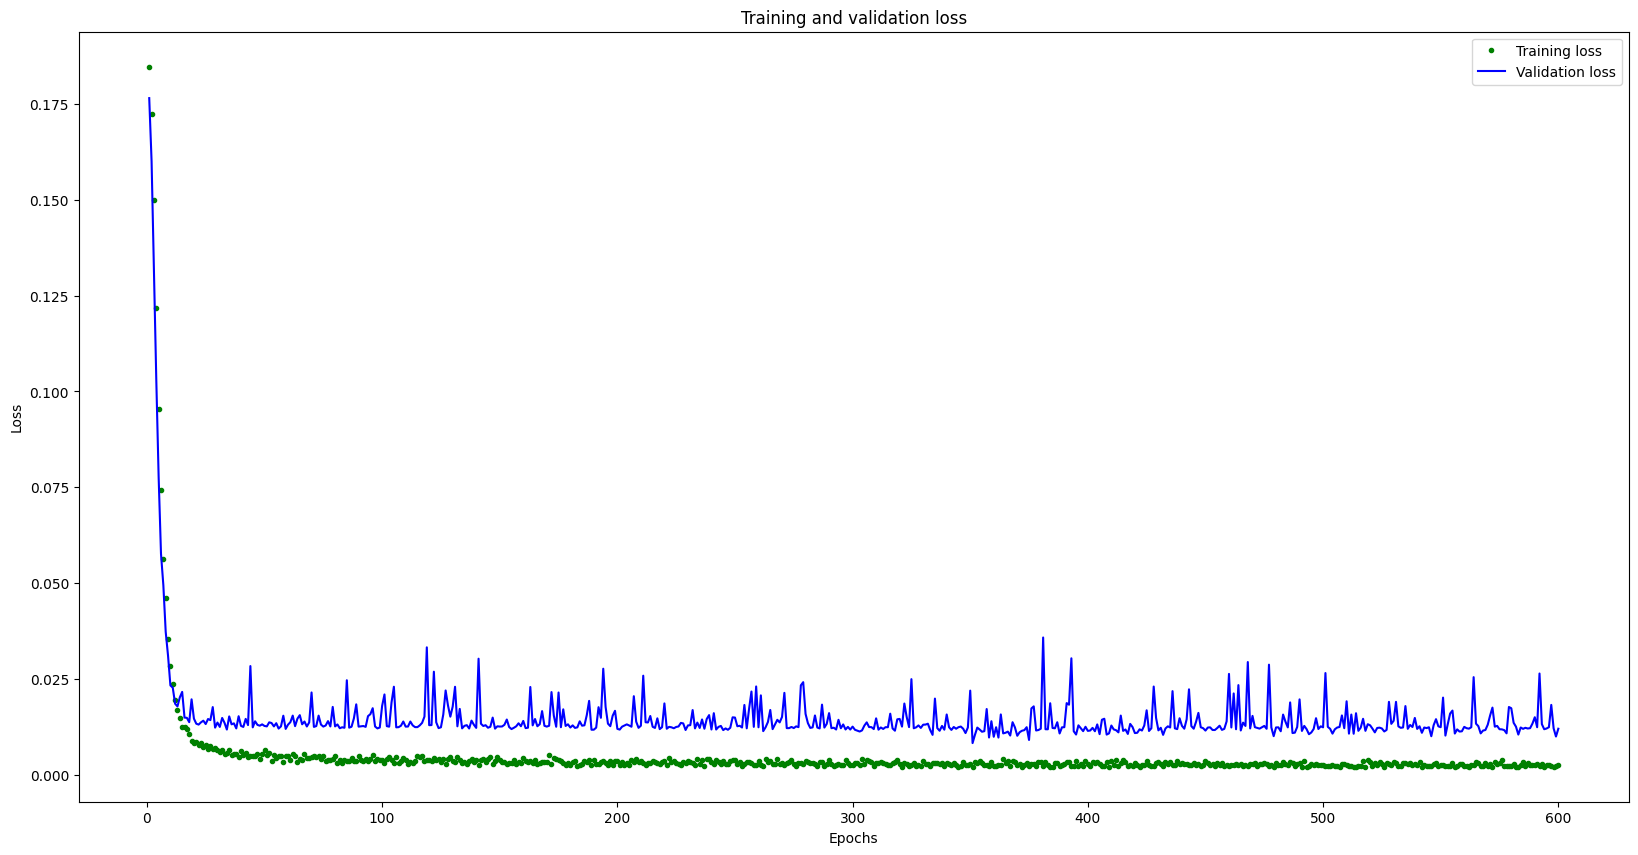

[20.0, 10.0]


In [55]:
plt.rcParams["figure.figsize"] = (20,10)

loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(loss) + 1)
plt.plot(epochs, loss, 'g.', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

print(plt.rcParams["figure.figsize"])

... and run some tests for the model predictions for constructing the confusion matrix

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step


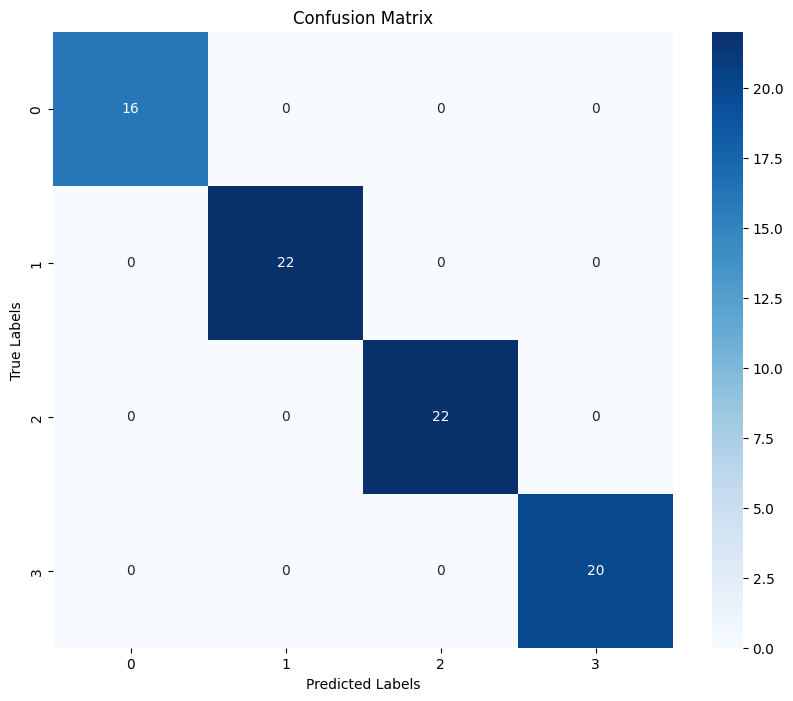




Total accuracy: 1.0

Per class specs: 
-> Rest
	 accuracy 1.0
	 true positive rate 1.0
	 true negative rate 1.0
	 positive predictive value 1.0
	 f1 score 1.0 
-> Left-right
	 accuracy 1.0
	 true positive rate 1.0
	 true negative rate 1.0
	 positive predictive value 1.0
	 f1 score 1.0 
-> Down-Up
	 accuracy 1.0
	 true positive rate 1.0
	 true negative rate 1.0
	 positive predictive value 1.0
	 f1 score 1.0 
-> Circle
	 accuracy 1.0
	 true positive rate 1.0
	 true negative rate 1.0
	 positive predictive value 1.0
	 f1 score 1.0 


In [56]:
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

predictions = model.predict(inputs_test)
y_pred_classes = np.argmax(predictions, axis=1)
y_true = np.argmax(outputs_test, axis=1)

cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(10, 8))
sns.heatmap(ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=np.unique(y_true)).confusion_matrix,annot=True,  cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

total_accuracy = np.trace(cm) / outputs_test.shape[0]
print("\n\n")
print(f"Total accuracy: {total_accuracy}\n")
print(f"Per class specs: ")
for i in range(len(gestures)):
  tp=cm[i,i]
  tn=0
  fp=0
  fn=0
  for r in range(len(gestures)):
      for c in range(len(gestures)):
        if (r==i):
          if (c!=i):
            fn+=cm[r,c]
        else:
          if (c==i):
            fp+=cm[r,c]
          else:
            tn+=cm[r,c]

  accuracy = (tp+tn)/(tp+tn+fp+fn)
  tpr=(tp)/(tp+fn)
  tnr=(tn)/(tn+fn)
  ppv=(tp)/(tp+fp)
  f1=(2*tp)/((2*tp)+fp+fn)
  print(f"-> {gestures[i]}")
  print(f"\t accuracy {accuracy}")
  print(f"\t true positive rate {tpr}")
  print(f"\t true negative rate {tnr}")
  print(f"\t positive predictive value {ppv}")
  print(f"\t f1 score {f1} ")

To prepare the arduino header file for the inference we need to convert the model in TensorflowLite and encode it in a contraint byte array.  

In [58]:
import os

converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

open("gesture_model.tflite", "wb").write(tflite_model)

basic_model_size = os.path.getsize("gesture_model.tflite")
print("Model is %d bytes" % basic_model_size)

!echo "const unsigned char model[] = {" > /content/model.h
!cat gesture_model.tflite | xxd -i      >> /content/model.h
!echo "};"                              >> /content/model.h
model_h_size = os.path.getsize("model.h")
print(f"Header file, model.h, is {model_h_size:,} bytes.")
print("\nOpen the side panel (refresh if needed). Double click model.h to download the file.")



Saved artifact at '/tmp/tmp5vfioeaw'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(1, 36), dtype=tf.float32, name='keras_tensor_40')
Output Type:
  TensorSpec(shape=(1, 4), dtype=tf.float32, name=None)
Captures:
  135341775198672: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135341775205008: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135341775204048: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135341775204240: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135341775204432: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135341775205584: TensorSpec(shape=(), dtype=tf.resource, name=None)
Model is 12760 bytes
Header file, model.h, is 78,722 bytes.

Open the side panel (refresh if needed). Double click model.h to download the file.
